In [624]:
# test-4-figure.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
%matplotlib inline

In [625]:
# specifying the path to the csv file that needs to be imported (the overlap.csv)
input_file_path = "/mnt/d/code/phd/image-analysis/synapse-counting/output_data/overlap.csv"

df = pd.read_csv(input_file_path)
print(df.head(3))

           image file name  overlap_um2  overlap_um2_rot  vglut1_threshold  \
0  OE_Exp1_IHC_Exp1_CA1_SO     6.861486         3.312811        989.434429   
1  OE_Exp1_IHC_Exp1_CA1_SO    14.328713         6.555935        989.434429   
2  OE_Exp1_IHC_Exp1_CA1_SR     7.837104         3.162716       1053.083197   

   psd95_threshold  
0       542.062486  
1       542.062486  
2       596.000658  


In [626]:
# transforming the df into the right format

# dropping the unneccesarry columns (vlgut1 threshold and psd95_threshold)
df_drop = df.drop(['vglut1_threshold', 'psd95_threshold'], axis=1)

# adding an extra element to the first column so that each observation is unique
df_drop["image file name"] = df_drop["image file name"] + "_" + (df_drop.groupby("image file name").cumcount() + 1).astype(str)

# pivoting the df into longer format
df_melted = pd.melt(df_drop, id_vars = ["image file name"], value_vars=["overlap_um2", "overlap_um2_rot"],
                    var_name="condition", value_name="overlap (um2)")

# replacing the names for the condition
df_melted["condition"] = df_melted["condition"].apply(lambda x: "rotated" if "overlap_um2_rot" in x else "actual")

# sorting the df based on the first column
df_sorted = df_melted.sort_values('image file name')

# have column that takes the hippocampal layer
df_sorted['hippocampal layer'] = df_sorted['image file name'].apply(lambda x: ' '.join(x.split('_')[-3:-1]))


print(df_sorted)

              image file name condition  overlap (um2) hippocampal layer
0   OE_Exp1_IHC_Exp1_CA1_SO_1    actual       6.861486            CA1 SO
20  OE_Exp1_IHC_Exp1_CA1_SO_1   rotated       3.312811            CA1 SO
1   OE_Exp1_IHC_Exp1_CA1_SO_2    actual      14.328713            CA1 SO
21  OE_Exp1_IHC_Exp1_CA1_SO_2   rotated       6.555935            CA1 SO
10  OE_Exp1_IHC_Exp1_CA1_SO_3    actual      16.821362            CA1 SO
30  OE_Exp1_IHC_Exp1_CA1_SO_3   rotated       7.976477            CA1 SO
11  OE_Exp1_IHC_Exp1_CA1_SO_4    actual       8.828803            CA1 SO
31  OE_Exp1_IHC_Exp1_CA1_SO_4   rotated       4.191939            CA1 SO
22  OE_Exp1_IHC_Exp1_CA1_SR_1   rotated       3.162716            CA1 SR
2   OE_Exp1_IHC_Exp1_CA1_SR_1    actual       7.837104            CA1 SR
23  OE_Exp1_IHC_Exp1_CA1_SR_2   rotated      21.125872            CA1 SR
3   OE_Exp1_IHC_Exp1_CA1_SR_2    actual      46.792118            CA1 SR
12  OE_Exp1_IHC_Exp1_CA1_SR_3    actual      28.469

In [627]:
import numpy as np
from matplotlib.patches import PathPatch

def adjust_box_widths(g, fac):
    """
    Adjust the widths of a seaborn-generated boxplot.
    """

    # iterating through Axes instances
    for ax in g.axes:

        # iterating through axes artists:
        for c in ax.get_children():

            # searching for PathPatches
            if isinstance(c, PathPatch):
                # getting current width of box:
                p = c.get_path()
                verts = p.vertices
                verts_sub = verts[:-1]
                xmin = np.min(verts_sub[:, 0])
                xmax = np.max(verts_sub[:, 0])
                xmid = 0.5*(xmin+xmax)
                xhalf = 0.5*(xmax - xmin)

                # setting new width of box
                xmin_new = xmid-fac*xhalf
                xmax_new = xmid+fac*xhalf
                verts_sub[verts_sub[:, 0] == xmin, 0] = xmin_new
                verts_sub[verts_sub[:, 0] == xmax, 0] = xmax_new

                # setting new width of median line
                for l in ax.lines:
                    if np.all(l.get_xdata() == [xmin, xmax]):
                        l.set_xdata([xmin_new, xmax_new])

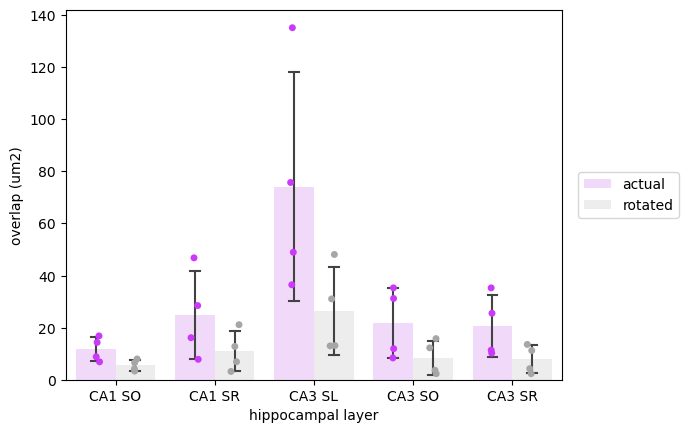

In [628]:
# #creating the plot
# fig = plt.figure(figsize=(5, 5))
# p = sns.stripplot(y="overlap (um2)", x="hippocampal layer", hue = "condition",
#                         data = df_sorted,
#                         jitter = False,
#                         dodge = 0.05,
#                         marker = "o",
#                         alpha = 0.5)

# sns.pointplot(y="overlap (um2)", x="hippocampal layer", hue = "condition",  
#               data=df_sorted, dodge=0.2, join=False, palette="dark",  
#               markers="_", scale=3, ax=p)

# sns.swarmplot(data=df_sorted, x="hippocampal layer", y="overlap (um2)", hue="condition", dodge=True)

# box = sns.boxplot(y="overlap (um2)", 
#             x="hippocampal layer", 
#             hue = "condition",
#             showmeans = True, 
#             meanline=True,
#             linewidth = 0.75,
#             meanprops={'color': 'k', 'ls': 'solid', 'lw': 1},
#             width = 0.6,
#             medianprops={'visible': False},
#             whiskerprops={'visible': False},
#             showfliers=False,
#             showbox=False,
#             showcaps=False,
#             zorder=0,
#             data=df_sorted, 
#             palette="dark",  
#             ax=p)

# adjust_box_widths(fig, 10)


# Draw the bar chart
ax = sns.barplot(
    data=df_sorted, 
    x="hippocampal layer", 
    y="overlap (um2)", 
    hue="condition",  
    errorbar="sd",
    palette=['#c92ffa', '#a6a7a5'],
    errwidth=1.5,
    capsize = 0.1, 
    alpha=0.2)


# Get the legend from just the bar chart
handles, labels = ax.get_legend_handles_labels()

# Draw the stripplot
sns.stripplot(
    data=df_sorted, 
    x="hippocampal layer", 
    y="overlap (um2)", 
    hue="condition", 
    dodge=True, 
    edgecolor=None, 
    linewidth=.75,
    ax=ax,
    palette=['#cb3afa', '#a6a7a5']
)

# Remove the old legend
ax.legend_.remove()

# Add just the bar chart legend back
ax.legend(
    handles,
    labels,
    loc=7,
    bbox_to_anchor=(1.25, .5),
)



In [629]:
# # exporting the plot as png
# output_folder = "/mnt/d/code/phd/image-analysis/synapse-counting/output_data/"

# output_file = os.path.join(output_folder, "dotplot.png")
# plot = p.get_figure()
# plot.savefig(output_file, dpi = 300)

In [630]:
# 

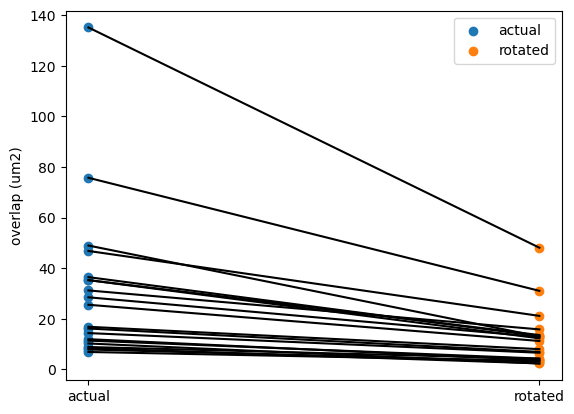

In [631]:
# Separate the data for actual and rotated conditions
actual_data = df_sorted[df_sorted["condition"] == "actual"]
rotated_data = df_sorted[df_sorted["condition"] == "rotated"]

# Create the plot
plt.scatter(np.zeros(len(actual_data)), actual_data["overlap (um2)"], label="actual")
plt.scatter(np.ones(len(rotated_data)), rotated_data["overlap (um2)"], label="rotated")

# Plot the lines connecting points
for i in range(len(actual_data)):
    plt.plot([0, 1], [actual_data.iloc[i]["overlap (um2)"], rotated_data.iloc[i]["overlap (um2)"]], c='k')

plt.xticks([0, 1], ['actual', 'rotated'])
plt.ylabel("overlap (um2)")
plt.legend()

plt.show()